# Семинар 8. Глобальная интерполяция

*Внимание! Семинар содержит интерактивные демонстрации. На сайте они представлены в статическом виде. Для работы интерактивных элементов необходимо скачать страницу в формате ipynb и запустить ipynb-файл локально.*

Перед изучением материалов семинара рекомендуем посетить лекцию или посмотреть видеозапись лекции. Ссылки (YouTube): [лекция 9](https://www.youtube.com/live/D1lAT1TLAv8?si=k2Wmd2gz_o6iO69_&t=2441) (начало темы), [лекция 10](https://www.youtube.com/live/TODavwxXtlU?si=OixRSBj-OXbIWhx4&t=15) (продолжение).

Предполагается, что читатель знает

* свойства интеграла Лебега (в общих чертах),
* конструкцию лебеговых пространств $L^p$ (в общих чертах) и классический пример такого пространства — пространство $L^2$,
* определение гильбертова пространства,
* теорему об обратной функции (для случая скалярной функции одного аргумента).

# Введение

Одной из важнейших задач вычислительной математики является **задача приближения функций**. Не вдаваясь в строгие определения, можно сказать, что эта задача заключается в **подборе по данной функции** (скалярной или векторной, одной или нескольких переменных) **другой функции, которая в каком-то** (заранее определённом) **смысле была бы близка к первой функции**. Исключительную важность сформулированной проблемы легко понять из следующего наблюдения.

Очень многие математические задачи, встречающиеся на практике, могут быть записаны в **обобщённом виде**:

$$b=Fa.$$

Здесь предполагается, что $a$ и $b$ являются элементами некоторых (линейных) **функциональных пространств** (вообще говоря, различных): $a\in M_a$, $b\in M_b$, — а через $F$ обозначен некоторый **оператор** (часто тоже линейный), переводящий элементы пространства $M_a$ в элементы пространства $M_b$. Задача заключается в том, чтобы по известному $a$ найти $b$, либо, наоборот, по известному $b$ найти $a$. Конкретные свойства пространств $M_a$, $M_b$ (например, их конечномерность, гильбертовость, сепарабельность и пр.) и оператора $F$ (например, его компактность, самосопряжённость и пр.) зависят от рассматриваемой задачи.

Если подходить к задачам указанного типа **формально**, то можно сказать, что первая их разновидность (нахождение $b$ по $a$) вовсе и не нуждается в решении; задача "уже решена" в том смысле, что написано правило отыскания $b$ по заданному $a$: оно заключается в действии на этот элемент $a$ оператором $F$. Аналогично можно легко "решить" и обратную задачу (нахождение $a$ по $b$) — для этого достаточно обратить исходное равенство: $a=F^{-1}b$ (правда, дополнительно нужно разъяснить, какой смысл вкладывается в обозначение $F^{-1}$). Вся сложность заключается в том, что в подавляющем большинстве случаев, интересных с точки зрения практики, нельзя указать **конструктивный** (т.е. реально применимый) способ поиска образа $Fa$ в пространстве $M_b$ (или прообраза $F^{-1}b$ в пространстве $M_a$), а иногда затруднительно даже строго доказать, что поставленная **задача корректна и имеет единственное решение** (с теоретической точки зрения только после доказательства последнего утверждения имеет смысл браться за решение задачи). Другими словами, **сложность задачи связана именно с действием оператором** $F$ или $F^{-1}$ на элементы соответствующего пространства: **чем "сложнее устроены" пространства и операторы, тем труднее с ними работать**, поскольку может быть непонятно, какие именно процедуры и в каком порядке нужно осуществлять.

Суть любого численного метода, применяемого в задачах рассматриваемого вида, сводится к тому, что поставленная задача **заменяется другой (более простой) задачей**

$$\beta=\mathcal{F}\alpha,$$

в которой $\alpha$ и $\beta$ — элементы пространств $\mathcal{M}_\alpha$ и $\mathcal{M}_\beta$ (вообще говоря, отличающихся от $M_a$ и $M_b$) соответственно, а $\mathcal{F}$ — оператор (в общем случае тоже отличный от $F$), отображающий $\mathcal{M}_\alpha$ в $\mathcal{M}_\beta$. Замена задачи производится так, чтобы действие оператором $\mathcal{F}$ (или $\mathcal{F}^{-1}$) на элементы пространства $\mathcal{M}_\alpha$ (или $\mathcal{M}_\beta$) было **легко осуществимым в вычислительном плане**, т.е. чтобы это действие включало **конечное число каких-то элементарных операций** и чтобы его было сравнительно **нетрудно алгоритмизовать** — именно эти свойства "новой" задачи важны в свете реализации метода на компьютере. Кроме того, **необходимо, чтобы из близости** (в каком-то заранее определённом смысле) **данных** двух задач (скажем, операторов $F$ и $\mathcal{F}$, а также элементов $a\in M_a$ и $\alpha\in\mathcal{M}_\alpha$) **следовала близость** (возможно, уже в ином смысле) **искомых решений** (в приведённом примере — элементов $b\in M_b$ и $\beta\in\mathcal{M}_\beta$). В противном случае замена одной задачи другой, очевидно, лишена практической ценности.

**Вот тут-то и возникает потребность приближать одни функции другими**, поскольку **функции могут являться элементами рассматриваемых пространств или играть роль операторов, действующих между пространствами**.

На прошлых семинарах мы рассмотрели уже по крайней мере две задачи, которые укладываются в приведённую общую схему: дифференцирование функций и решение уравнений вида $\textbf{f}(\textbf{x})=\textbf{0}$ (левая часть может быть как линейной, так и нелинейной функцией одной или нескольких переменных со значениями в $\mathbb{R}^n$). Правда, при постановке этих задач мы почти не подчёркивали их операторного характера, а при разборе численных методов не пользовались идеей приближения функций, хотя такой подход был вполне возможен. Например, формулы численного дифференцирования (см. семинар 2) можно было бы выводить не с помощью метода неопределённых коэффициентов, а путём действия оператором $D_k\equiv d^k/dx^k$ на какую-то функцию, заменяющую (приближающую в некотором смысле) исходную (табличную) функцию; именно так поступают во многих учебниках. Ещё одну задачу, допускающую операторную формулировку, мы рассмотрим в следующих семинарах, когда будем обсуждать **методы численного интегрирования**. Один из классов этих методов будет строиться именно с позиций приближения интегрируемых функций другими функциями (интерполянтами). Наконец, в операторных терминах формулируется вся **теория разностных схем**, а многие конкретные разностные схемы, применяемые для решения дифференциальных уравнений, строятся с использованием методов приближения функций (в качестве примера можно привести **интерполяционно-характеристические разностные схемы** для уравнения переноса, которые мы будем изучать в следующем семестре).

В нашем курсе мы будем подробно обсуждать лишь один способ приближения функций — **интерполяцию**. Существуют и другие способы (например, равномерные приближения, среднеквадратичные приближения и др.), детальное рассмотрение которых вследствие недостатка времени остаётся за рамками наших семинаров.

# Постановка задачи интерполяции

В дальнейшем ради простоты и краткости обозначений мы рассматриваем случай **скалярных функций одной (вещественной) переменной**.

Напомним определения сетки, сеточной функции и сеточной проекции, которые мы давали на втором семинаре.

**Определение 1.** Будем говорить, что на отрезке $[a,b]$ введена *сетка*, если задано *конечное* множество

$$G=\{x_i\in\mathbb{R},\phantom{-}0\leq i\leq n:\phantom{-}a\leq x_0<x_1<\dots<x_n\leq b\}.$$

Точки $x_i$ будем называть *узлами сетки*, а величины $h_i=x_i-x_{i-1}$, $1\leq i\leq n$ — её *шагами*. Если $h_1=h_2=\dots=h_n\equiv h$, то сетка называется *равномерной*.

**Определение 2.** Пусть на отрезке $[a,b]$ введена сетка $G$. *Сеточной функцией* называется *конечное* множество пар

$$\mathscr{F}=\big\{(y,x):\phantom{-}y\in\mathbb{R},\phantom{-}x\in G\big\},$$

в котором каждое значение $x$ принадлежит *лишь одной паре*. Величины $f$ называются *значениями сеточной функции*.

**Определение 3.** Пусть дана функция $f\in L^p[a,b]$. *Проекцией* функции $f$ на сетку $G$ называется сеточная функция

$$\mathscr{F}_f=\big\{(f(x),x):\phantom{-}x\in G\big\},$$

где $G$ — некоторая сетка, введённая на отрезке $[a,b]$. Операция построения сеточной функции $\mathscr{F}_f$ по функции $f$ с помощью правила $y_i=f(x_i)$, $0\leq i\leq n$, называется *проектированием функции $f$ на сетку* (или сеточным проектированием).

Очевидно, что **при фиксированной сетке $G$** (заданной на отрезке $[a,b]$) **множество сеточных функций, построенных на этой сетке, представляет собой линейное пространство**; обозначим его через $\text{Gf}\,[a,b]$. Таким образом, проектирование некоторой гладкой функции на заданную сетку можно рассматривать как действие оператора $R$, отображающего элементы пространства $L^p[a,b]$ в элементы пространства $\text{Gf}\,[a,b]$ (по правилу $y_i=f(x_i)$). Часто при рассмотрении сеточного проектирования с этой точки зрения элементы пространства $L^p[a,b]$ называют **функциями-оригиналами**. Действие оператора $R$ заключается, образно говоря, в том, что он "обрезает" функцию-оригинал, "выкидывая" континуальные множества точек из областей её определения и значения.

На практике, как правило, полагают $p=2$, т.е. в качестве функций-оригиналов рассматривают элементы пространства $L^2[a,b]$, поэтому далее вместо $L^p[a,b]$ мы везде будем писать $L^2[a,b]$. Строго говоря, в роли элементов этого пространства (как и любого пространства $L^p[a,b]$) выступают не сами функции (измеримые по Лебегу), а **классы эквивалентности функций** (другими словами, множества $L^p[a,b]$ являются фактор-пространствами). Напомним, что норма в пространстве $L^2[a,b]$ порождается скалярным произведением: $||f||=\sqrt{(f,f)}$, где

$$(f,g)=\int\limits_{a}^{b}\mathop{dx}f(x)g(x)$$

(а метрика $\rho$ индуцируется этой нормой: $\rho(f, g)=||f-g||$). Здесь функции $f$ и $g$ предполагаются вещественнозначными, а интеграл понимается как интеграл Лебега. Хорошо известно, что **пространство** $L^2[a,b]$ (с указанным скалярным произведением) **является гильбертовым**. Отметим, что вместо отрезка $[a,b]$ везде выше можно было бы указывать произвольное множество $E$, измеримое по Лебегу.

Подчеркнём, что **отображение** $R$ из $L^2[a,b]$ в $\text{Gf}\,[a,b]$ **не является инъективным**. Иначе говоря, **одной и той же сеточной функции могут соответствовать разные функции-оригиналы**. Действительно, на сетке из узлов $x_n=\pi n$, где $n$ — целое неотрицательное число, не превосходящее $N\in\mathbb{N}$, можно определить, например, тождественно нулевую сеточную функцию (т.е. функцию, принимающую нулевые значения во всех узлах $x_n$). В качестве функций-оригиналов для этой сеточной функции могут выступать функции вида $f(x)=A\sin{x}$, поскольку $\sin x_n=0$. В данном примере одной и той же сеточной функции отвечает даже континуальное множество функций-оригиналов, поскольку $A\in\mathbb{R}$.

Наряду с оператором $R$, осуществляющим сеточное проектирование, естественно рассматривать также оператор $I$, переводящий элементы пространства $\text{Gf}\,[a,b]$ в элементы пространства $L^2[a,b]$. Функция, $\widetilde f\in L^2[a,b]$, поставленная оператором $I$ в соответствие сеточной функции $\mathscr{F}_f$, называется **функцией-образом**.

**Упражнение.** Являются ли операторы $R$ и $I$ линейными?

Подействуем на некоторый элемент $f\in L^2[a,b]$ сначала оператором $R$, а потом оператором $I$, т.е. совершим следующую цепочку преобразований:

$$f\in L^2[a,b]\quad\xrightarrow{R}\quad\mathscr{F}_f\in\text{Gf}\,[a,b]\quad\xrightarrow{I}\quad\widetilde f\in L^2[a,b].$$

Здесь функция-оригинал сначала была спроектирована на некоторую сетку $G$, а затем по полученной проекции была построена функция-образ. Можно сказать, что действие оператором $R$ "стёрло" часть информации о функции $f$, превратив её в элемент другого функционального пространства, а оператор $I$ восстановил функцию из исходного пространства, пользуясь информацией, сохранившейся в конечном числе точек. Ясно, что функция $\widetilde f$, вообще говоря, отличается от функции $f$, и можно ставить **вопрос о близости функции-оригинала и функции-образа**, т.е. выяснять, насколько успешным оказалось восстановление функции. С теоретической точки зрения этот вопрос решается вычислением расстояния между функциями $f$ и $\widetilde f$. Последнее возможно благодаря тому, что $f,\widetilde f\in L^2[a,b]$: выше мы отметили, что $\rho(f,\widetilde f)=||f-\widetilde f||$. Здесь не последнюю роль играют "хорошие" свойства пространства $L^2[a,b]$: в процессе теоретических построений (ими мы заниматься не будем) можно воспользоваться, например, его гильбертовостью.

На практике функции-оригиналы обычно неизвестны, и часто приходится иметь дело с **восстановлением функций по заданной сеточной функции**. Другими словами, отпадает первое преобразование из рассмотренной выше цепочки — требуется осуществить только второе из них:

$$\mathscr{F}_f\in\text{Gf}\,[a,b]\quad\xrightarrow{I}\quad\widetilde f\in L^2[a,b].$$

Очевидно, что при такой постановке вопроса нельзя оценить качество восстановления исходной функции $f\in L^2[a,b]$ оператором $I$ по предложенному выше способу: поскольку на практике обычно неизвестны ни функция $\widetilde f$, ни какие-либо её свойства, вычислить расстояние $\rho(f, \widetilde f)$ затруднительно. Сравнение же известных функций $\mathscr{F}_f$ и $\widetilde f$ лишено смысла, поскольку это **элементы разных функциональных пространств**.

Выход из указанного затруднения довольно очевиден. Можно спроектировать функцию $\widetilde f$ на заданную сетку (ту же, что и у функции $\mathscr{F}_f$) и сравнивать на предмет близости уже функции $\mathscr{F}_f$ и $\mathscr{F}_\tilde{f}$. Понятие близости двух сеточных функций (построенных на одной сетке) легко формализовать с помощью следующего определения.



**Определение 4.** Пусть $\mathscr{F},\mathscr{G}\in \text{Gf}\,[a,b]$, т.е.

$$\mathscr{F}=\big\{(y,x):\phantom{-}y\in\mathbb{R}, \phantom{-}x\in G\big\},\quad
  \mathscr{G}=\big\{(z,x):\phantom{-}z\in\mathbb{R},\phantom{-}x\in G\big\},$$

где $G$ — некоторая сетка, введённая на отрезке $[a,b]$ и содержащая $n+1$ узлов. *Вектором-разностью сеточных функций* $\mathscr{F}$ и $\mathscr{G}$ называется вектор длины $n+1$, составленный из разностей значений этих сеточных функций:

$$\text{vec}(\mathscr{F}-\mathscr{G})\equiv
  \begin{pmatrix}
    y_0-z_0 & y_1-z_1 & \dots & y_n-z_n
  \end{pmatrix}^\text{T}.$$

Очевидно, что, имея в виду определение 4, легко ввести метрику в пространстве $\text{Gf}\,[a,b]$ — достаточно положить $\rho(\mathscr{F},\mathscr{G})=||\text{vec}(\mathscr{F}-\mathscr{G})||$, где $||\cdot||$ — произвольная векторная норма в пространстве $\mathbb{R}^{n+1}$.

**Упражнение.** Убедитесь, что предложенная функция $\rho$ действительно является метрикой на $\text{Gf}\,[a,b]$.

На практике обычно считают, что сеточные функции $\mathscr{F}$ и $\mathscr{G}$ близки, если $\rho(\mathscr{F},\mathscr{G})=0$, т.е. проще говоря, если вектор-разность $\text{vec}(\mathscr{F}- \mathscr{G})$ равен нулевому вектору.

Вернёмся к задаче восстановления функции-образа по известной сеточной функции и выпишем всю цепочку действий операторами $R$ и $I$ (включая и первое преобразование с неизвестной функцией $f\in L^2[a,b]$):

$$f\in L^2[a,b]\quad\xrightarrow{R}\quad\mathscr{F}_f\in\text{Gf}\,[a,b]\quad\xrightarrow{I}\quad\widetilde f\in L^2[a,b]\quad\xrightarrow{R}\quad \mathscr{F}_\tilde{f}\in\text{Gf}\,[a,b].$$

С учётом сказанного выше, условимся считать задачу восстановления функции $\widetilde{f}$ оператором $I$ по функции $\mathscr{F}_f$ решённой, если $\rho(\mathscr{F}_f,\mathscr{F}_\tilde{f})=0$. Другими словами, в узлах сетки $G$, введённой на отрезке $[a,b]$, значения функций $\widetilde{f}$ и $\mathscr{F}_f$ должны совпадать. Поставленная задача называется **задачей глобальной точной интерполяции**. Оператор $I$ часто называется **оператором интерполяции**, а функцию-образ $\widetilde{f}$ ещё называют **интерполянтом**. Отметим, что термином "интерполяция" принято пользоваться в тех случаях, когда граничные точки сетки $G$, введённой на отрезке $[a,b]$, совпадают с граничными точками этого отрезка, т.е. когда **функция восстанавливается только в точках, лежащих между какими-либо двумя узлами заданной сетки**. Если это требование не выпонено (т.е. функция восстанавливается "за пределами" сетки), то говорят об **экстраполяции**.

Подчеркнём, что из требования $\rho(\mathscr{F}_f,\mathscr{F}_\tilde{f})=0$, которое мы положили в основу формулировки задачи интерполяции, не следует, вообще говоря, никакой информации о величине $\rho(f,\widetilde{f})$. В самом деле, в силу свойств интеграла Лебега расстояние $\rho(f,\widetilde{f})$ не меняется при изменении функций $f$ и $\widetilde{f}$ на множестве лебеговой меры нуль (а любое конечное множество точек отрезка $[a,b]$ имеет как раз меру нуль). Значит, всегда можно "подогнать" значения функций $f$ и $\widetilde{f}$ так, чтобы условие $\rho(\mathscr{F}_f,\mathscr{F}_\tilde{f})=0$ выполнилось, не изменив при этом величины $\rho(f,\widetilde{f})$.

Другими словами, **близость сеточных проекций функции-оригинала и функции-образа ещё не влечёт близости самих функции-оригинала и функции-образа**. В связи с этим обычно утверждают, что **задача интерполяции некорректна**. Грубо говоря, это значит, что **если некоторая функция $\widetilde f$ повторяет неизвестную функцию $f$ в конечном числе точек, то отсюда ещё не следует, что функция $\widetilde f$ "хорошо приближает" функцию $f$**.

В отдельных случаях некоторые сведения о функции-оригинале всё-таки известны. Например, может быть известно, что функция-оригинал $f$ является гладкой. Иногда могут быть доступны значения производных функции $f$. Существенен также сам способ задания её сеточной проекции $\mathscr{F}_f$: в одних случаях узлы сетки могут быть зафиксированными, а в других случаях может быть доступно вычисление значений функции $f$ в произвольно выбранных узлах. Учёт этих (и других) особенностей позволяет конструировать различные способы интерполяции, улучшающие (в некоторым смысле) приближение функции-оригинала $f$ функцией-образом $\widetilde{f}$.

Наряду с задачей **глобальной интерполяции**, сформулированной выше, рассматривается также задача **локальной интерполяции**. Если в первом случае, как мы видели, интерполянт задаётся **сразу на всём отрезке** $[a,b]$, то во втором случае для каждого подотрезка $[x_i,x_{i+1}]$, образованного узлами сетки, строится свой (локальный) интерполянт, а в узлах сетки осуществляется **сшивка** полученных интерполянтов (по возможности, гладкая). Иначе говоря, **при локальной интерполяции функция-образ задаётся на отрезке $[a,b]$ кусочно** (по-возможности, кусочно-гладко). Локальную интерполяцию называют ещё интерполяцией **сплайнами** (ранее английский термин "spline" означал гибкую чертёжную линейку, которой пользовались для графического кусочно-гладкого интерполирования функций). О сплайнах мы будем говорить на одном из следующих семинаров.

# Алгебраическая интерполяция

Наиболее простой способ глобальной интерполяции на отрезке $[a,b]$ сводится к составлению по сеточной функции $\mathscr{F}_f$ **обобщённого полинома**

$$\widetilde f=\sum\limits_{k=0}^n c_k\varphi_k(x),$$

в котором $c_k$ — числовые коэффициенты, а $\varphi_k(x)$ — некоторая система функций, определённых на отрезке $[a,b]$. Функции $\varphi_k$ часто называются **базисными функциями**.

**Условие интерполяционности** $y_i=\widetilde{f}(x_i)$ (здесь $y_i$ — значения сеточной функции $\mathscr{F}_f$) принимает вид СЛАУ на коэффициенты $c_k$:

$$\sum\limits_{k=0}^n c_k\varphi_k(x_i)=y_i,\quad 0\leq i\leq n.$$

Введя те же обозначения, что и при рассмотрении МНК (см. семинар 5):

$$\begin{gather}
  \textbf{c}=\big(c_0,\,c_2,\,\dots,\,c_n\big)^\text{T};\quad \textbf{y}=\big(y_0,\,y_2,\,\dots,\,y_n\big)^\text{T};\\[0.2cm]
  \boldsymbol{\varphi}_k=\big(\varphi_k(x_0),\,\varphi_k(x_2),\,\dots,\,\varphi_k(x_n)\big)^\text{T},\quad 0\leq k\leq n;\\[0.2cm]
  \textbf{G}_\varphi=(g_{ik}),\quad g_{ik}=\varphi_k(x_i),\quad 0\leq i,\,k\leq n,
  \end{gather}$$

можно переписать получившуюся СЛАУ в векторно-матричной форме:

$$\textbf{G}_\varphi\textbf{c}=\textbf{y}.$$

Подчеркнём, что в данном случае (в отличие от случая МНК) матрица $\textbf{G}_\varphi$ является квадратной (и имеет порядок $n+1$).

Как известно, СЛАУ $\textbf{G}_\varphi\textbf{c}=\textbf{y}$ имеет единственное решение, если система столбцов $\boldsymbol{\varphi}_k$ является **линейно независимой**. На пятом семинаре мы видели, что это условие выполнено при любом выборе узлов сетки, если в качестве базисных функций выбраны мономы $\boldsymbol{\varphi}_k(x)=x^k$, $0\leq k\leq n$. В этом случае обобщённый полином принимает вид **алгебраического полинома**

$$\widetilde{f}=\sum_{k=0}^{n} c_k x^{k}\equiv P_n(x)$$

и сама интерполяция называется алгебраической. Таким образом, справедлива теорема.

**Теорема 1.** Для сеточной функции $\mathscr{F}_f\in\text{Gf}\,[a,b]$, заданной в $n+1$ узлах, существует *единственный* алгебраический полином

$$P_n(x)=\sum_{k=0}^{n} c_k x^{k}$$

степени не выше $n$, решающий задачу глобальной точной интерполяции на отрезке $[a,b]$, т.е. обеспечивающий выполнение *условия интерполяционности*

$$y_i=P_n(x_i),\quad 0\leq i\leq n.$$

Здесь $y_i$ — значения функции $\mathscr{F}_f$.

Как видим, для осуществления алгебраической интерполяции достаточно найти коэффициенты $c_k$ путём решения СЛАУ $\textbf{G}_\varphi\textbf{c}=\textbf{y}.$ Однако, как уже отмечалось на семинаре 5, при больших $n$ эта СЛАУ оказывается очень плохо обусловленной. Поэтому на практике алгебраические интерполянты строят иначе. Мы рассмотрим **две возможные формы записи интерполяционных полинов: Лагранжа и Ньютона**.

## Интерполяционный полином в форме Лагранжа

Пусть на отрезке $[a,b]$ введена сетка с узлами $\big\{x_i\big\}_{i=0}^n$. Определим на том же отрезке **вспомогательные функции** $\ell_i(x)$:

$$\ell_i(x)=\prod_{\substack{k=0 \\ k\ne i}}^{n}\frac{x-x_k}{\,x_i-x_k\,},\quad 0\leq i\leq n.$$

Легко видеть, что они представляют собой многочлены степени $n$, причём $\ell_i(x_j)=\delta_{ij}$. Именно последнее свойство позволяет легко записать интерполяционный полином:

$$P_n(x)=\sum_{i=0}^{n} y_i\,\ell_i(x).$$

Условие интерполяционности (см. теорему 1), очевидно, удовлетворяется:

$$P_n(x_j)=\sum_{i=0}^{n} y_i\,\ell_i(x_j)=y_j,\quad 0\leq j\leq n.$$

Иногда интерполяционный полином в форме Лагранжа записывают несколько иначе: вводят функцию

$$\omega(x)=\prod_{k=0}^{n}(x-x_k)$$

и замечают, что

$$\ell_i(x)=\frac{\omega(x)}{(x-x_i)\cdot\omega'(x_i)}.$$

Тогда

$$P_n(x)=\sum_{i=0}^{n} \frac{y_i\cdot\omega(x)}{(x-x_i)\cdot\omega'(x_i)}.$$

**Упражнение.** Докажите равенство

$$\ell_i(x)=\frac{\omega(x)}{(x-x_i)\cdot\omega'(x_i)}.$$

## Задача 1

Для сеточной функции

$$
\begin{array}{c|cccc}
  x_i & -3 & -2 & -1 & 0 \\
  \hline
  y_i & 16 & 7 & 4 & 1
\end{array}
$$

построить интерполяционный полином в форме Лагранжа.

**Решение.** Интерполяционный полином в форме Лагранжа имеет следующий вид:

$$P_3(x)=\sum_\limits{i=0}^3 y_i\,\ell_i(x).$$

Ясно, что в данном случае это многочлен степени не выше третьей, поскольку каждая из вспомогательных функций $\ell_i$ есть алгебраический полином степени $n$, а из условия задачи следует, что $n=3$, так как нумерацию узлов сетки мы начинаем с нуля (всего узлов четыре).

Выпишем вспомогательные функции:

$$\begin{gather}
  \ell_0(x)=
  \prod_{\substack{k=0 \\ k\neq 0}}^{3}\frac{x-x_k}{\,x_0-x_k\,}=
  \frac{(x-x_1)(x-x_2)(x-x_3)}{(x_0-x_1)(x_0-x_2)(x_0-x_3)}=
  \frac{(x+2)(x+1)(x-0)}{(-3+2)(-3+1)(-3-0)}
=-\frac{x^3}{6}-\frac{x^2}{2}-\frac{x}{3};\\[0.2cm]
  \ell_1(x)=
  \prod_{\substack{k=0 \\ k\neq 1}}^{3}\frac{x-x_k}{\,x_1-x_k\,}=
  \frac{(x-x_0)(x-x_2)(x-x_3)}{(x_1-x_0)(x_1-x_2)(x_1-x_3)}=
  \frac{(x+3)(x+1)(x-0)}{(-2+3)(-2+1)(-2-0)}=
  \frac{x^3}{2}+2x^2+\frac{3}{2}x;\\[0.2cm]
  \ell_2(x)=
  \prod_{\substack{k=0 \\ k\neq 2}}^{3}\frac{x-x_k}{\,x_2-x_k\,}=
  \frac{(x-x_0)(x-x_1)(x-x_3)}{(x_2-x_0)(x_2-x_1)(x_2-x_3)}=
  \frac{(x+3)(x+2)(x-0)}{(-1+3)(-1+2)(-1-0)}=
  -\frac{x^3}{2}-\frac{5}{2}x^2-3x;\\[0.2cm]
  \ell_3(x)=
  \prod_{\substack{k=0 \\ k\neq 3}}^{3}\frac{x-x_k}{\,x_3-x_k\,}=
  \frac{(x-x_0)(x-x_1)(x-x_2)}{(x_3-x_0)(x_3-x_1)(x_3-x_2)}=
  \frac{(x+3)(x+2)(x+1)}{(0+3)(0+2)(0+1)}
  =\frac{x^3}{6}+x^2+\frac{11}{6}x+1.
  \end{gather}
$$

Подставляя значения сеточной функции $y_i$ и найденные вспомогательные функции $\ell_i$ в формулу для $P_3$, получаем искомый интерполяционный полином:

$$P_3(x)=16\,\ell_0(x)+7\,\ell_1(x)+4\,\ell_2(x)+\ell_3(x)=-x^3-3x^2-5x+1.$$


Те же действия можно было бы выполнить с помощью функции ```interpolating_poly``` библиотеки ```sympy``` ([документация](https://docs.sympy.org/latest/modules/polys/reference.html#sympy.polys.specialpolys.interpolating_poly)). Эта функция принимает на вход количество узлов сетки ```n``` (указывается именно **количество**, а не наибольший номер узла, т.е. в нашем случае ```n=4```), независимую переменную ```x``` и таблицу значений сеточной функции в виде списков ```X``` и ```Y```. Возвращается интерполяционный полином в форме Лагранжа (объект класса ```Poly```):

In [19]:
from sympy import symbols, interpolating_poly

x = symbols('x')
poly_Lagr = interpolating_poly(n=4, x=x, X=[-3, -2, -1, 0], Y=[16, 7, 4, 1])
poly_Lagr

-8*x*(x + 1)*(x + 2)/3 + 7*x*(x + 1)*(x + 3)/2 - 2*x*(x + 2)*(x + 3) + (x + 1)*(x + 2)*(x + 3)/6

Упростить полином, представив его в виде суммы мономов (т.е. "собрать" коэффициенты при степенях аргумента), можно с помощью функции ```expand``` ([документация](https://docs.sympy.org/latest/tutorials/intro-tutorial/simplification.html#expand)):

In [20]:
from sympy import expand

expand(poly_Lagr)

-x**3 - 3*x**2 - 5*x + 1

## Интерполяционный полином в форме Ньютона

Интерполяционный полином в форме Лагранжа удобен для теоретических построений, но его не очень удобно строить на практике — получаются громоздкие выкладки. Поэтому при вычислениях часто пользуются интерполяционным полиномом в форме Ньютона. Для его записи необходимо ввести понятие **разделённых разностей**. Они определяются рекуррентно.

**Определение 5.** Пусть на отрезке $[a,b]$ введена сетка $G$, состоящая из $n+1$ узлов, и определена функция $f=f(x)$. Тогда

*  разделёнными разностями *нулевого порядка* называются значения функции $f$ в узлах сетки (в количестве $n+1$):

   $$f(x_i)\equiv f(x_i),\quad 0\leq i\leq n;$$

*  разделёнными разностями *первого порядка* называются отношения (в количестве $n$):

   $$f(x_i,\,x_{i+1})\equiv\frac{f(x_{i+1})-f(x_i)}{x_{i+1}-x_{i}},\quad 0\leq i\leq n-1;$$

*  разделёнными разностями *второго порядка* называются отношения (в количестве $n-1$):

   $$f(x_i,\,x_{i+1},\,x_{i+2})\equiv\frac{f(x_{i+1},\,x_{i+2})-f(x_{i},x_{i+1})}{x_{i+2}-x_{i}},\quad 0\leq i\leq n-2;$$

*  наконец, разделёнными разностями *$k$-го порядка* называются отношения (в количестве $n-k+1$):

   $$f(x_i,\,x_{i+1},\,\dots,\,x_{i+k})\equiv\frac{f(x_{i+1},\,\dots,\,x_{i+k})-f(x_{i},\,\dots,\,x_{i+k-1})}{x_{i+k}-x_{i}},\quad 0\leq i\leq n-k.$$

Из определения ясно, что **на сетке из $n+1$ узла можно построить разделённые разности вплоть до $n$-го порядка включительно, причём разность наивысшего порядка будет всего одна**.

Можно показать, что любая разделённая разность является симметричной функцией своих аргументов, т.е. не изменяется при их перестановке. Кроме того, оказывается, что существует точка $\xi\in [a,b]$ такая что,

$$f(x_i,\,x_{i+1},\,\dots,\,x_{i+k})=\frac{f^{(k)}(\xi)}{k!}$$

(разумеется, если функция $f$ является $k$ раз дифференцируемой).

Введём для "первых" (т.е. получающихся при $i=0$) разностей каждого порядка обозначения:

$$\Delta_0=f(x_0),\quad \Delta_1=f(x_0,\,x_1),\quad\dots,\quad \Delta_k=f(x_0,\,\dots\,x_k),\quad\dots$$

(иногда ради краткости их используют для обозначения произвольных разделённых разностей, а не только "первых"). Тогда интерполяционный полином в форме Ньютона можно записать так:

$$\begin{align}
  P_n(x)&=\Delta_0+\Delta_1(x-x_0)+\Delta_2(x-x_0)(x-x_1)+\dots+\Delta_n(x-x_0)\dots(x-x_{n-1})=\\[0.2cm]
 &=\sum\limits_{k=0}^n\Delta_k\cdot\prod\limits_{j=0}^{k-1}(x-x_j).
  \end{align}$$

Существует и другой способ его записи, для которого вводятся "последние" разделённые разности

$$\widetilde\Delta_0=f(x_n),\quad \widetilde\Delta_1=f(x_{n-1},\,x_n),\quad\dots,\quad \widetilde\Delta_k=f(x_{n-k},\,\dots\,x_n),\quad\dots\,.$$

Тогда

$$\begin{align}
  P_n(x)&=\widetilde\Delta_0+\widetilde\Delta_1(x-x_n)+\widetilde\Delta_2(x-x_n)(x-x_{n-1})+\dots+\widetilde\Delta_n(x-x_n)\dots(x-x_{1})=\\[0.2cm]
 &=\sum\limits_{k=0}^n\widetilde\Delta_k\cdot\prod\limits_{j=n-k+1}^{n}(x-x_j).
  \end{align}$$

Чтобы различать эти формы записи, первую называют полиномом **"вперёд"**, а вторую — полиномом **"назад"**.

Упомянутая выше связь разделённых разностей и производных позволяет считать интерполяционный полином в форме Ньютона **разностным аналогом формулы Тейлора**.

Выполнение условия интерполяционности для полинома в форме Ньютона неочевидно — его приходится специально доказывать (например, по индукции). Зато на практике полином в форме Ньютона более удобен, например, тем, что при добавлении узлов в сетку не требуется полностью перестраивать весь полином (как это пришлось бы делать при записи в форме Лагранжа): достаточно добавить к уже имеющемуся полиному несколько слагаемых.

На практике для построения интерполяционного полинома в форме Ньютона составляют **таблицу разделённых разностей**. Мы покажем, как это делается, на примере следующей задачи.

## Задача 2

Для сеточной функции

$$
\begin{array}{c|cccc}
  x_i & -3 & -2 & -1 & 0 \\
  \hline
  y_i & 16 & 7 & 4 & 1
\end{array}
$$

(той же, что и в задаче 1) построить интерполяционный полином в форме Ньютона. Найти значение функции в точке $x=-2,5$, используя линейную, квадратичную  и кубическую интерполяцию. Вычислить (приближённо) производную функции в граничных узлах сетки.

**Решение.** Построим таблицу разделённых разностей (см. рисунок).

![image](pic/sem08_table1.png)

*Таблица разделённых разностей к решению задачи 2*

В соответствии с приведённым выше определением, каждая разделённая разность из таблицы получается составлением дифференциального отношения для разностей предыдущего порядка, причём **база (т.е. делитель) дифференциального отношения всегда берётся максимально широкой**. Например, при составлении первой из величин $\Delta_2$ мы взяли разность "соседних" величин $\Delta_1$ (т.е. $-9-(-3)=-9+3=-6$) и поделили её именно на **максимально широкую** базу $x_0-x_2$ (т.е. на $-3-(-1)=-3+1=-2$), а не на базы $x_0-x_1$ или $x_1-x_2$, которые можно было бы составить из узлов, задействованных при вычислении рассматриваемых разностей $\Delta_1$.

Остаётся выписать интерполяционный полином в форме Ньютона, двигаясь по верхней (красные числа) или нижней (зелёные числа) косым строкам таблицы. Значение $-1$ разделённой разности $\Delta_3$ (выделено жирным шрифтом) входит в оба варианта полинома (поэтому оно и не выделено ни красным, ни зелёным цветом).

Итак, первый вариант записи (красные числа) — **полином "вперёд"**:

$$\begin{gather}
  P_3(x)=\Delta_0+\Delta_1\cdot(x-x_0)+\Delta_2\cdot(x-x_0)(x-x_1)+\Delta_3\cdot(x-x_0)(x-x_1)(x-x_2)=\\
  =16-9\cdot(x+3)+3\cdot(x+3)(x+2)-1\cdot(x+3)(x+2)(x+1);
  \end{gather}$$

второй вариант записи (зелёные числа) — **полином "назад"** (напомним, что у нас $n=3$):

$$\begin{gather}
  P_3(x)=\widetilde\Delta_0+\widetilde\Delta_1\cdot(x-x_{n-0})+\widetilde\Delta_2\cdot(x-x_{n-0})(x-x_{n-1})+\widetilde\Delta_3\cdot(x-x_{n-0})(x-x_{n-1})(x-x_{n-2})=\\
  =1-3\cdot(x-0)+0\cdot(x-0)(x+1)-1\cdot(x-0)(x+1)(x+2).
  \end{gather}$$

Упростив эти два полинома, легко убедиться в том, что они, как и положено, совпадают и друг с другом, и с интерполяционным полиномом Лагранжа, построенным при решении задачи 1:

$$P_3(x)=-x^3-3x^2-5x+1.$$

Сразу можно вычислить искомые значения производной:

$$P_3'(x)=-3x^2-6x-5,\quad P_3'(-3)=-14,\quad P_3'(0)=-5.$$

Подчеркнём, что значения производной в граничных точках сетки можно было бы быстро вычислить и без предварительного упрощения полинома. Чтобы найти производную в **правой** граничной точке, надо взять полином **"назад"**, отбросить его свободный член, выкинуть из каждого слагаемого скобку, зануляющуюся при подстановке правой граничной точки, и найти значение полученного полинома в этой точке. Иначе говоря,

$$P'(0)=\big[-3+0\cdot(x+1)-1\cdot(x+1)(x+2)\big]_{x=0}=-5.$$

В квадратных скобках мы переписали приведённый выше полином "назад", проигнорировав его свободный член и скобку $(x-0)$ в каждом слагаемом (так как в правой граничной точке она зануляется).

Аналогичное правило справедливо и для вычисления значения производной в **левом** граничном узле: надо взять полином **"вперёд"** без свободного члена, отбросить скобку, зануляющуюся на левой границе, и найти значение получившегося полинома. В нашем примере:

$$P'(-3)=\big[-9+3\cdot(x+2)-1\cdot(x+2)(x+1)\big]_{x=-3}=-14.$$

**Упражнение.** Обоснуйте упомянутые правила быстрого вычисления производных в граничных точках.

Требуемую по условию задачи кубическую интерполяцию мы построили: $P_3(x)=-x^3-3x^2-5x+1$. Для построения квадратичной интерполяции, надо выбросить из полинома слагаемое с разделённой разностью третьего порядка $\Delta_3$. Ориентируясь на полином "вперёд", получаем:

$$P_2(x)=16-9\cdot(x+3)+3\cdot(x+3)(x+2)=3x^2+6x+7.$$

Аналогично получаем линейную интерполяцию (отбрасываем разделённые разности $\Delta_2$ и $\Delta_3$):

$$P_1(x)=16-9\cdot(x+3)=-9x-11.$$

Таким образом,

$$P_3(-2,5)=10,375,\quad P_2(-2,5)=10,75,\quad P_1(-2,5)=11,5.$$

В дополнение к предложенному аналитическому решению напишем функцию ```diffs_table```, вычисляющую таблицу разделённых разностей по таблице значений сеточной функции (заданной в виде двух массивов):

In [21]:
import numpy as np

def diffs_table(x: np.ndarray, y: np.ndarray):
    k = len(y) # количество узлов сетки (совпадает с количеством разделённых разностей)
    diffs = np.zeros([k, k])
    diffs[:, 0] = y # нулевые разделённые разности - значения самой сеточной функции

    for j in range(1, k):
        for i in range(k-j):
            diffs[i, j] = (diffs[i+1, j-1] - diffs[i, j-1]) / (x[i+j] - x[i])

    return diffs

Протестируем функцию на примере из задачи:

In [22]:
x = [-3, -2, -1, 0]
y = [16,  7,  4, 1]

diffs_table(x, y)

array([[16., -9.,  3., -1.],
       [ 7., -3.,  0.,  0.],
       [ 4., -3.,  0.,  0.],
       [ 1.,  0.,  0.,  0.]])

Как видим, таблица строится правильно, хотя и не очень наглядно: в каждом столбце разности "сдвинуты вверх", так что $j$-й столбец содержит $n+1-j$ разделённых разностей $j$-го порядка в первых $n+1-j$ строках ($0\leq j\leq n$).

Используя функцию ```diffs_table```, можно написать программу, вычисляющую значение интерполяционного полинома в форме Ньютона в произвольной точке $\xi$. Для определённости будем строить полином "вперёд":

In [23]:
def Newton_poly_forward(x: np.ndarray, y: np.ndarray, xi: float):
    diffs = diffs_table(x, y) # строим таблицу разделённых разностей

    coeffs = diffs[0, :] # коэффициенты - первая строка таблицы
    x_factors = [1]

    for i in range(0, len(coeffs)-1):
        x_factors.append(x_factors[-1]*(xi - x[i]))

    return coeffs @ x_factors

С помощью этой программы можно проверить полученное при решении задачи равенство $P_3(-2,5)=10,375$:

In [24]:
float(Newton_poly_forward(x, y, -2.5))

10.375

**Упражнение.** Так ли хороша предложенная программа? Какие проблемы могут возникнуть при её использовании?

*Указание.* Как в написанной программе вычисляется значение интерполяционного полинома в заданной точке $\xi$? См. также численную демонстрацию с полиномами Чебышёва из раздела "МНК в Python" семинара 5.

**Упражнение.** Напишите аналогичную функцию ```Newton_poly_backward```, вычисляющую значение полинома "назад" в произвольной точке $\xi$.

Функция ```Newton_poly_forward``` позволяет легко визуализировать построенный кубический полином $P_3$:

In [25]:
import matplotlib.pyplot as plt

def graph_Newton(x: np.ndarray, y: np.ndarray):
    func = lambda xi: Newton_poly_forward(x, y, xi)
    func = np.vectorize(func)

    grid = np.arange(np.min(x), np.max(x) + 0.01, 0.01)
    P = func(grid)

    fig, ax = plt.subplots()
    ax.scatter(x, y, color='blue')
    ax.plot(grid, P, color='red')

    ax.set_xlabel("$x$")
    ax.set_ylabel("$y$")

    plt.title("Интерполяционный полином в форме Ньютона")

    plt.show()

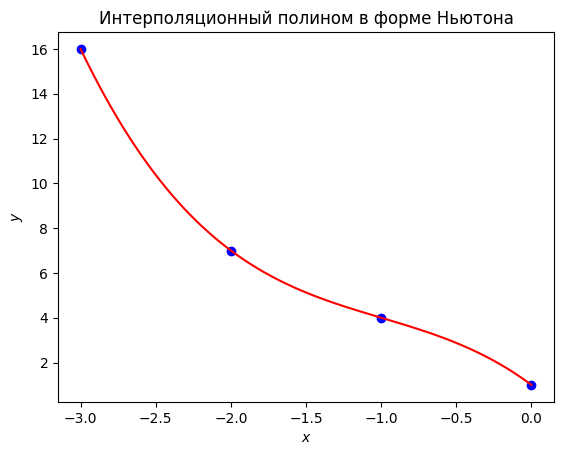

In [26]:
graph_Newton(x, y)

Любопытно вернуться к примеру из первого семинара (см. раздел "Введение", подраздел "Пример 2"), в котором демонстрировалась плохая обусловленность задачи неточной интерполяции, решавшейся методом наименьших квадратов, и повторить аналогичную демонстрацию, но уже с функцией ```Newton_poly_forward```. Напомним, что суть примера состоит в интерполяции сеточной функции $\mathscr{F}_n$ со случайными значениями (и вполне определёнными узлами) при различных $n$. Составим соответствующую программу:

In [27]:
from ipywidgets import interact, IntSlider

n_w = IntSlider(min=1, max=50, step=1, value=10)

def test(n: int):
    x = np.pi * np.linspace(-1.0, 0.0, n+1, endpoint=True) # задаём узлы
    x = np.cos(x)
    x = np.sort(x) # упорядочиваем узлы по возрастанию

    y = np.random.rand(n+1)

    graph_Newton(x, y)

interact(test, n=n_w);

interactive(children=(IntSlider(value=10, description='n', max=50, min=1), Output()), _dom_classes=('widget-in…

**Упражнение.** Что происходит при больших $n$? Чем это объясняется? Как это исправить?

**Упражнение.** В программе выше закомментируйте строку, в которой производится сортировка массива ```x```. Является ли эта строка обязательной для корректной работы программы?

## Задача 3

На равномерной сетке из трёх точек **двумя способами** построить формулу для вычисления производной в крайней правой точке: первый раз использовать метод неопределённых коэффициентов, второй — приближение сеточной функции интерполянтом.

**Решение.** Как и во втором семинаре, обозначим узлы сетки через $x_{m-2}$, $x_{m-1}$ и $x_m$, а соответствующие значения дифференцируемой функции $f$ — через $f_{m-2}$, $f_{m-1}$ и $f_m$. Вводим неопределённые коэффициенты (их должно быть три — по числу точек):

$$f'_m=\frac{Af_{m-2}+Bf_{m-1}+Cf_m}{h}.$$

Раскладываем первые два члена числителя по формуле Тейлора вблизи $x_m$. Достаточно получить члены вплоть до $h^2$, поскольку члены с $h^3$ не удастся сократить ни при каких значениях коэффициентов (максимальный порядок аппроксимации первой производной на трёхточечном шаблоне — второй). Остаточные члены для краткости не выписываем. Имеем:

$$\begin{align}
    f_{m-2}&=f(x_m-2h)=\varphi_m-2h \varphi_m'+\frac{(2h)^2}{2}\varphi''_m;\\[0.2cm]
    f_{m-1}&=f(x_m-h)=\varphi_m-h \varphi_m'+\frac{h^2}{2}\varphi''_m.
  \end{align}$$

Подставляя эти разложения в формулу для $f'_m$ и группируя члены с одинаковыми степенями $h$, получаем:

$$f'_m=\frac{1}{h}(A+B+C)\varphi_m+(-2A-B)\varphi'_m+\frac{h}{2}(4A+B)\varphi_m''.$$

Сравнение левой и правой частей приводит к системе уравнений:

$$\begin{cases}
    A+B+C=0,\\
    -2A-B=1,\\
    4A+B=0.
  \end{cases}$$

Её решение:

$$A=\frac{1}{2},\quad B=-2,\quad C=\frac{3}{2}.$$

Искомая формула:

$$f'_m=\frac{f_{m-2}-4f_{m-1}+3f_m}{2h}.$$

Тот же ответ можно получить другим способом — построить интерполяционный полином (например, в форме Ньютона) и найти его производную. Составим таблицу разделённых разностей:

![image](pic/sem08_table2.png)

*Таблица разделённых разностей к решению задачи 3*

Производную в правой граничной точке будем находить по правилу, упоминавшемуся в решении предыдущей задачи. Для этого нам нужен полином "назад". Выписываем его по последней косой строке таблицы:

$$P_2(x)=f_m+\frac{f_m-f_{m-1}}{h}(x-x_m)+\frac{f_{m-2}-2f_{m-1}+f_m}{2h^2}(x-x_m)(x-x_{m-1}).$$

Пользуемся правилом: зачёркиваем свободный член и скобку $(x-x_m)$. В получившийся полином вместо $x$ подставляем $x_m$:

$$P_2'(x)=\frac{f_m-f_{m-1}}{h}+\frac{f_{m-2}-2f_{m-1}+f_m}{2h^2}(x_m-x_{m-1})=\frac{f_{m-2}-4f_{m-1}+3f_m}{2h}\equiv f'_m.$$

Как видим, получилась та же формула численного дифференцирования.

# Решение нелинейных уравнений с помощью обратной интерполяции

Приближение функций интерполяционными полиномами можно использовать для решения нелинейных уравнений. Соответствующий метод обычно называется **методом обратной интерполяции**. Его суть заключается в следующем.

Пусть требуется решить нелинейное уравнение вида $g(x)=0$. Будем считать, что искомый корень $x=\xi$ локализован на отрезке $[a,b]$, причём функция $g=g(x)$ непрерывна и **строго монотонна** на этом отрезке. Дополнительно предположим, что образ отрезка $U=\big\{f(x)\in\mathbb{R}:\phantom{,}x\in[a,b]\big\}$ является числовым промежутком (отрезком, интервалом, полуинтервалом). Тогда, согласно теореме об обратной функции, на числовом промежутке $U$ определена функция $g^{-1}\equiv f:\phantom{,}U\to [a,b]$, которая, как и исходная функция $g$, строго монотонна и непрерывна. Очевидно, из равенства $g(\xi)=0$ следует, что $f(0)=\xi$.

Разумеется, если есть возможность **аналитически** обратить функцию $g$, то для решения нелинейного уравнения не нужно никакой интерполяции: достаточно вычислить значение найденной обратной функции в нуле. Однако на практике обратить нелинейную функцию почти никогда не удаётся. Поэтому можно поступить так:

* ввести на отрезке локализации $[a,b]$ сетку и построить сеточную проекцию $\mathscr{G}_g$ функции $g$,
* обратить сеточную функцию $\mathscr{G}_g$ (т.е. просто поменять местами числа в каждой паре "аргумент-значение", входящей в функцию $\mathscr{G}_g$) — в результате получится (обратная) сеточная функция $\mathscr{F}_f$,
* построить для функции $\mathscr{F}_f$ интерполяционный полином $P_n$ и найти (приближённо) искомый корень как величину $P_n(0)$.

В отличие от знакомых нам по шестому семинару методов численного решения нелинейных уравнений, **предложенный алгоритм не является итерационным**. Этим объясняется его главный недостаток: **прямой контроль точности приближения к корню здесь невозможен**. Ошибку интерполяции можно оценить теоретически (мы сделаем это на следующем семинаре), но в оценку войдёт максимум $(n+1)$-й производной приближаемой функции, поэтому на практике эта оценка почти бесполезна.

Отметим, что существуют методы численного решения нелинейных уравнений, включающие обратную интерполяцию в качестве составной части более сложного алгоритма. Например, в шестом семинаре мы упоминали, что "настоящий" метод Брента на каждой итерации использует обратную квадратичную интерполяцию, сочетая её с построением хорд и дихотомией.

## Задача 4

Найти **положительный** корень уравнения $\sin x + x^2-1=0$ методом обратной интерполяции.

**Решение.** Это уравнение мы уже рассматривали на шестом семинаре. В частности, нами было установлено, что его положительный корень локализован на отрезке $[0,1]$, а (непрерывная) функция $g(x)=\sin x + x^2-1$ строго возрастает при всех $x\geq 0$. Таким образом, существует строго монотонная (более конкретно — тоже строго возрастающая) обратная функция $f=g^{-1}$, поэтому применение метода обратной интерполяции оправданно.

Запрограммируем функцию ```create_inv_table```, проецирующую исходную функцию $g$ на сетку с заданным числом узлов $k=n+1$ и возвращающую таблицу значений **уже обращённой** сеточной функции (т.е. функции $\mathscr{F}_f$). Для определённости полагаем, что граничные узлы сетки совпадают с граничными точками отрезка локализации корня (мы включаем границы отрезка в сигнатуру функции ```create_inv_table``` в виде кортежа).

In [28]:
import numpy as np

def create_inv_table(g, bracket: tuple, k: int):
    x = np.linspace(bracket[0], bracket[1], k) # равномерная сетка из k узлов
    y = np.vectorize(g)(x)

    return y, x

Остаётся применить написанную выше (при решении задачи 2) функцию ```Newton_poly_forward```:

In [29]:
def solve_inverse_interp(g, bracket: tuple, n: int):
    x, y = create_inv_table(g, (0, 1), n)

    return float(Newton_poly_forward(x, y, 0))

Посмотрим, как меняется получаемое приближение к корню в зависимости от количества узлов сетки $n+1$:

In [30]:
from ipywidgets import interact, IntSlider

n_w = IntSlider(min=1, max=50, step=1, value=4)

def test_solver(n: int):
    g = lambda x: np.sin(x) + x**2 - 1
    x = solve_inverse_interp(g, (0, 1), n)
    print('Приближение к корню:', x)

interact(test_solver, n=n_w);

interactive(children=(IntSlider(value=4, description='n', max=50, min=1), Output()), _dom_classes=('widget-int…

Найденное приближение к корню можно сравнить с приближением, полученным, например, встроенной функцией ```brentq``` (мы обсуждали её на пятом семинаре):

In [31]:
from scipy.optimize import brentq

g = lambda x: np.sin(x) + x**2 - 1

brentq(g, 0, 1, xtol=1e-16)

0.6367326508052821

Как видим, метод обратной интерполяции показал неплохой результат: при $n=50$ он дал 13 верных знаков корня. Правда, расчёт проводится сравнительно долго (по вполне понятной причине — из-за присутствия в функции ```Newton_poly_forward``` циклов):

In [32]:
%time brentq(g, 0, 1, xtol=1e-16)

CPU times: user 111 µs, sys: 4 µs, total: 115 µs
Wall time: 119 µs


0.6367326508052821

In [33]:
%time solve_inverse_interp(g, (0, 1), 50)

CPU times: user 2.86 ms, sys: 0 ns, total: 2.86 ms
Wall time: 2.8 ms


0.6367326508052429

**Упражнение.** В демонстрации, приведённой после задачи 2, мы видели, что при больших $n$ функция ```Newton_poly_forward``` выдаёт некорректный результат. Однако в последних примерах нам удалось запустить её при $n=50$ без видимых проблем. Как разрешается это противоречие?

# Практические задачи

## Задача А

1. Модифицировать предложенную в тексте семинара программу, реализующую построение интерполяционного полинома в форме Ньютона, так, чтобы избежать численного эффекта, продемонстрированного в примере после задачи 2. Предусмотреть возможность построения полиномов "вперёд" и "назад". Предусмотреть возможность быстрого подсчёта приближённых значений производных в граничных узлах сетки.

2. Применить написанную программу для построения интерполянтов следующих функций:

   $$f(x)=e^{x},\quad f(x)=x^{4},\quad f(x)=\frac{1}{1+25x^{2}}.$$

   Во всех трёх случаях использовать равномерную сетку из $N=n+1$ узлов на отрезке $[-1,1]$.

3. Написать программу, осуществляющую **кусочно-линейную** интерполяцию заданной сеточной функции. На примере трёх функций из предыдущего пункта сравнить результаты глобальной интерполяции многочленом степени $n$ с результатами кусочно-линейной интерполяцией (на той же сетке). При каких $n$ лучший результат даёт глобальная интерполяция, а при каких — кусочно-линейная?


# Литература и другие источники

**Видеозаписи:**

1. Вычислительная математика — лекция 9. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/D1lAT1TLAv8?si=k2Wmd2gz_o6iO69_&t=2441) (YouTube).

2. Вычислительная математика — лекция 10. Лектор — Е.Н. Аристова. [Ссылка](https://www.youtube.com/live/TODavwxXtlU?si=OixRSBj-OXbIWhx4&t=15) (YouTube).

3. Вычислительная математика — лекция 7. Лектор — А.В. Чикиткин. [Ссылка](https://youtu.be/APP3N4MxCT8?si=gSv6vp0BmdD9XkPa) (YouTube).

4. Интерполяция — видеоразбор темы. Преподаватель — Т.Ю. Салихова. [Ссылка](https://vkvideo.ru/video-212608323_456239030) (VK Видео).

5. Алгебраическая интерполяция — видеоразбор задачи. Преподаватель — А.И. Лопато. [Ссылка](https://vkvideo.ru/video-212608323_456239022) (VK Видео).

**Рекомендуемая литература (с комментариями):**

1.  *В.И. Косарев. 12 лекций по вычислительной математике* — лекция 5, стр. 62—75.

2.  *А.А. Самарский, А.В. Гулин. Численные методы* — параграфы 1 (стр. 127—132), 5 и 6 (стр. 148—161) главы 3. Остальные параграфы этой главы следует читать в связи с изучением материалов следующих семинаров.

3.  *А.А. Амосов, Ю.А. Дубинский, Н.В. Копченова. Вычислительные методы для инженеров* — глава 11, параграфы 11.1—11.3 (стр. 292—302), а также 11.7—11.10 (стр. 311—332).

4.  *В.И. Крылов, В.В. Бобков, П.И. Монастырный. Начала теории вычислительных методов. Интерполирование и интегрирование.* Основные понятия теории интерполяции изложены в параграфах 1—3 (стр. 8—42). О приложениях интерполяции к численному дифференцированию и решению уравнений можно прочитать в параграфах 5—6 (стр. 49—76).

5.  *Н.С. Бахвалов, Н.П. Жидков, Г.М. Кобельков. Численные методы* — глава 2, параграфы 1—5 (стр. 35—48).

Дополнительная литература:

6. *Р.С. Пастушков. Задачи и упражнения по вычислительной математике. V семестр. Решения, указания, ответы.* Напомним, что это пособие есть в библиотеке МФТИ. В электронном виде его легче всего скачать с сайта О.А. Пырковой (см. ниже).

**Сайты и другие электронные ресурсы:**

1. Персональный сайт преподавателя МФТИ О.А. Пырковой. Содержит много полезных материалов по различным математическим курсам МФТИ. Страница с материалами осеннего семестра по вычислительной математике: [ссылка](https://www.pyrkovaoa-fizteh.ru/консультация-вычм-5/).

2. Scientific Python Lectures. Очень полезный ресурс, представляющий собой учебник по научному программированию на языке Python. Представлено много различных библиотек. Есть pdf-версия. Все материалы на английском языке. [Ссылка.](https://lectures.scientific-python.org/)

3. Python Programming And Numerical Methods: A Guide For Engineers And Scientists. Прекрасный сайт, представляющий собой электронную версию одноимённой книги по научному программированию на Python. Исключительно подробное изложение с многочисленными примерами. [Ссылка.](https://pythonnumericalmethods.studentorg.berkeley.edu/notebooks/Index.html)

# Контрольные вопросы

1. Какую роль играют методы приближения функций в вычислительной математике?
2. Что такое сетка, сеточная функция, проекция функции на сетку?
3. Что такое функция-оригинал и функция-образ? Каким функциональным пространствам они принадлежат? Можно ли сравнивать их напрямую?
4. Сформулируйте задачу глобальной точной интерполяции.
5. Почему задачу интерполяции называют некорректной?
6. Чем локальная интерполяция отличается от глобальной?
7. Что такое обобщённый полином? Как формулируется условие интерполяционности при приближении функции обобщённым полиномом?
8. В чём суть алгебраической интерполяции? При каких условиях для заданной сеточной функции можно построить алгебраический интерполяционный полином?
9. Почему нельзя найти коэффициенты алгебраического интерполянта путём решения СЛАУ?
10. Запишите две формулы для вспомогательных функций $\ell_i(x)$ и интерполяционный полином в форме Лагранжа.
11. Что такое разделённые разности?
12. Каков наивысший порядок разделённой разности, которую можно построить на сетке из $n+1$ узлов?
13. Сколько разделённых разностей $k$-го порядка можно построить на сетке из $n+1$ узлов?
14. Как связаны разделённая разность $k$-порядка и $k$-я производная приближаемой функции?
15. Выпишите два варианта интерполяционного полинома в форме Ньютона. Какую формулу из курса математического анализа напоминает этот полином?
16. Перечислите достоинства и недостатки интерполяционных полиномов в формах Лагранжа и Ньютона.
17. Как строится и для чего используется таблица разделённых разностей?
18. В чём состоит метод обратной интерполяции решения нелинейных уравнений?
19. Можно ли достичь наперёд заданной точности при решении нелинейного уравнения методом обратной интерполяции?
20. В чём сходство и различие методов Брента и обратной интерполяции решения нелинейных уравнений?

*Версия от 28.10.2025*